In [1]:
import pandas as pd

file_path = "../data/final_syros/final_syros/all_filtered_ais.csv"

df_sample = pd.read_csv(file_path, nrows=1000)

print("Rows:", len(df_sample))
print("Columns:")
print(df_sample.columns.tolist())

df_sample.head()

Rows: 1000
Columns:
['MMSI', 'UTC', 'TIMESTAMP', 'LON', 'LAT', 'SOG', 'COG', 'HEADING', 'STATUS', 'STATUS_DESC']


,MMSI,UTC,TIMESTAMP,LON,LAT,SOG,COG,HEADING,STATUS,STATUS_DESC
0,439729450,2024-07-01T00:00:04Z,1719792004,25.481133,37.330250,22.6,275.6,277,0,Under way using engine
1,353196028,2024-07-01T00:00:05Z,1719792005,25.325942,37.450587,0.0,232.4,0,0,Under way using engine
2,241856948,2024-07-01T00:00:05Z,1719792005,24.791303,37.173427,13.2,235.6,234,0,Under way using engine
3,541257875,2024-07-01T00:00:07Z,1719792007,25.863415,37.661092,10.7,172.2,173,0,Under way using engine
4,243681675,2024-07-01T00:00:08Z,1719792008,25.147962,37.087337,0.0,66.2,335,0,Under way using engine


In [2]:
print("Shape:", df_sample.shape)

print("\nData types:")
print(df_sample.dtypes)

print("\nMissing values:")
print(df_sample.isnull().sum())

print("\nBasic statistics:")
display(df_sample.describe())

Shape: (1000, 10)

Data types:
MMSI             int64
UTC                str
TIMESTAMP        int64
LON            float64
LAT            float64
SOG            float64
COG            float64
HEADING          int64
STATUS           int64
STATUS_DESC        str
dtype: object

Missing values:
MMSI           0
UTC            0
TIMESTAMP      0
LON            0
LAT            0
SOG            0
COG            0
HEADING        0
STATUS         0
STATUS_DESC    0
dtype: int64

Basic statistics:


,MMSI,TIMESTAMP,LON,LAT,SOG,COG,HEADING,STATUS
count,1.000000e+03,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,4.801398e+08,1.719793e+09,25.318333,37.399046,7.769400,187.077700,152.683000,3.280000
std,1.443271e+08,3.600288e+02,0.374071,0.108136,9.323804,119.917406,135.705986,5.836237
min,2.288249e+08,1.719792e+09,24.772127,37.086852,0.000000,0.000000,0.000000,0.000000
25%,3.703850e+08,1.719792e+09,24.945196,37.337788,0.000000,66.200000,0.000000,0.000000
50%,4.397294e+08,1.719793e+09,25.325947,37.436830,0.100000,206.050000,145.000000,0.000000
75%,5.412579e+08,1.719793e+09,25.447296,37.442467,18.100000,280.600000,276.000000,5.000000
max,7.836160e+08,1.719793e+09,26.019258,37.712127,22.700000,359.500000,355.000000,15.000000


In [ ]:
# See the available AIS columns
print(df_sample.columns.tolist())

# Look at one vessel's records
vessel_id = df_sample["MMSI"].iloc[0]

vessel = df_sample[df_sample["MMSI"] == vessel_id].copy()

print("Vessel:", vessel_id)
print("Number of records:", len(vessel))

display(vessel)

['MMSI', 'UTC', 'TIMESTAMP', 'LON', 'LAT', 'SOG', 'COG', 'HEADING', 'STATUS', 'STATUS_DESC']
Vessel: 439729450
Number of records: 176


,MMSI,UTC,TIMESTAMP,LON,LAT,SOG,COG,HEADING,STATUS,STATUS_DESC
0,439729450,2024-07-01T00:00:04Z,1719792004,25.481133,37.330250,22.6,275.6,277,0,Under way using engine
5,439729450,2024-07-01T00:00:10Z,1719792010,25.480217,37.330333,22.5,275.5,277,0,Under way using engine
9,439729450,2024-07-01T00:00:16Z,1719792016,25.479567,37.330383,22.6,275.8,277,0,Under way using engine
22,439729450,2024-07-01T00:00:35Z,1719792035,25.477067,37.330583,22.5,275.5,277,0,Under way using engine
40,439729450,2024-07-01T00:00:52Z,1719792052,25.474650,37.330783,22.6,275.6,277,0,Under way using engine
...,...,...,...,...,...,...,...,...,...,...
974,439729450,2024-07-01T00:20:05Z,1719793205,25.324617,37.341450,22.4,275.0,276,0,Under way using engine
977,439729450,2024-07-01T00:20:10Z,1719793210,25.323967,37.341500,22.4,274.9,276,0,Under way using engine
981,439729450,2024-07-01T00:20:16Z,1719793216,25.323050,37.341550,22.4,274.7,276,0,Under way using engine
989,439729450,2024-07-01T00:20:22Z,1719793222,25.322400,37.341600,22.4,274.8,276,0,Under way using engine


In [ ]:
import folium

# Select the first vessel
vessel_id = df_sample["MMSI"].iloc[0]
vessel = df_sample[df_sample["MMSI"] == vessel_id].copy()

# Create map centered on the vessel
m = folium.Map(
    location=[vessel["LAT"].mean(), vessel["LON"].mean()],
    zoom_start=8
)

# Add vessel positions
for _, row in vessel.iterrows():
    folium.CircleMarker(
        location=[row["LAT"], row["LON"]],
        radius=4,
        popup=f"MMSI: {row['MMSI']}<br>Time: {row['UTC']}",
    ).add_to(m)

m

In [ ]:
m.save("../data/vessel_map.html")
print("Map saved!")

Map saved!


In [ ]:
import pandas as pd

file_path = "../data/final_syros/final_syros/all_filtered_ais.csv"

df = pd.read_csv(file_path, nrows=50000)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (50000, 10)
        MMSI                   UTC   TIMESTAMP        LON        LAT   SOG  \
0  439729450  2024-07-01T00:00:04Z  1719792004  25.481133  37.330250  22.6   
1  353196028  2024-07-01T00:00:05Z  1719792005  25.325942  37.450587   0.0   
2  241856948  2024-07-01T00:00:05Z  1719792005  24.791303  37.173427  13.2   
3  541257875  2024-07-01T00:00:07Z  1719792007  25.863415  37.661092  10.7   
4  243681675  2024-07-01T00:00:08Z  1719792008  25.147962  37.087337   0.0   

     COG  HEADING  STATUS             STATUS_DESC  
0  275.6      277       0  Under way using engine  
1  232.4        0       0  Under way using engine  
2  235.6      234       0  Under way using engine  
3  172.2      173       0  Under way using engine  
4   66.2      335       0  Under way using engine  


In [7]:
vessel_counts = df["MMSI"].value_counts()

print("Number of unique vessels:", df["MMSI"].nunique())

print("\nTop 10 vessels:")
print(vessel_counts.head(10))

Number of unique vessels: 124

Top 10 vessels:
MMSI
531004359    3745
370384996    3714
353196028    3120
616620391    2039
449094058    1975
243681675    1905
261098615    1879
533187847    1263
248964690    1260
680520589    1246
Name: count, dtype: int64


In [8]:
vessel_id = vessel_counts.index[0]

vessel = df[df["MMSI"] == vessel_id].copy()

print("Selected vessel:", vessel_id)
print("Number of AIS points:", len(vessel))

Selected vessel: 531004359
Number of AIS points: 3745


In [10]:
import folium

# 1. Sort vessel records chronologically note this
vessel = vessel.sort_values("TIMESTAMP").copy()

# 2. Create an interactive map centered on the vessel's positions
m = folium.Map(
    location=[
        vessel["LAT"].mean(),
        vessel["LON"].mean()
    ],
    zoom_start=9
)

# 3. Extract latitude and longitude coordinates
route = vessel[["LAT", "LON"]].values.tolist()

# 4. Draw the vessel trajectory
folium.PolyLine(
    route,
    weight=3,
    opacity=0.8,
    tooltip=f"Vessel {vessel_id}"
).add_to(m)

# 5. Mark the starting position
folium.Marker(
    [vessel.iloc[0]["LAT"], vessel.iloc[0]["LON"]],
    tooltip="Start"
).add_to(m)

# 6. Mark the final position
folium.Marker(
    [vessel.iloc[-1]["LAT"], vessel.iloc[-1]["LON"]],
    tooltip="End"
).add_to(m)

# 7. Display the map
m
# Step 8: Analyze vessel movement

print("Vessel:", vessel_id)
print("AIS points:", len(vessel))

print("\nSpeed (SOG):")
print(vessel["SOG"].describe())

print("\nCourse (COG):")
print(vessel["COG"].describe())

print("\nTime range:")
print("Start:", vessel["TIMESTAMP"].min())
print("End:", vessel["TIMESTAMP"].max())

Vessel: 531004359
AIS points: 3745

Speed (SOG):
count    3745.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: SOG, dtype: float64

Course (COG):
count    3745.000000
mean      225.871482
std        87.398891
min         0.000000
25%       253.900000
50%       253.900000
75%       260.000000
max       280.600000
Name: COG, dtype: float64

Time range:
Start: 1719792011
End: 1719832661


In [12]:


print("Total records:", len(df))

print("\nSOG statistics:")
print(df["SOG"].describe())

print("\nSOG value counts:")
print(df["SOG"].value_counts().head(10))

print("\nPercentage of records with SOG > 0:")
positive_sog = (df["SOG"] > 0).mean() * 100
print(f"{positive_sog:.2f}%")

Total records: 50000

SOG statistics:
count    50000.000000
mean        11.961594
std         12.744951
min          0.000000
25%          0.000000
50%          8.600000
75%         21.700000
max         42.900000
Name: SOG, dtype: float64

SOG value counts:
SOG
0.0     15265
0.1      2267
0.2       491
8.7       404
32.7      391
32.9      371
32.6      342
24.7      339
32.8      338
8.2       327
Name: count, dtype: int64

Percentage of records with SOG > 0:
69.47%


In [13]:


vessel_stats = (
    df.groupby("MMSI")
    .agg(
        ais_points=("MMSI", "size"),
        moving_points=("SOG", lambda x: (x > 0).sum()),
        avg_speed=("SOG", "mean"),
        max_speed=("SOG", "max")
    )
    .sort_values("moving_points", ascending=False)
)

display(vessel_stats.head(10))

,ais_points,moving_points,avg_speed,max_speed
MMSI,,,,
616620391,2039,1958,27.881069,34.5
449094058,1975,1932,28.892051,34.0
261098615,1879,1855,32.096381,42.9
248964690,1260,1244,28.944683,34.4
243681675,1905,1233,10.073176,21.0
533187847,1263,1225,19.759541,25.1
680520589,1246,1211,20.906742,25.7
477832320,1120,1104,27.520893,33.4
439729450,1140,1091,17.675351,25.4


In [1]:
# Find vessels with useful movement data

vessel_stats = (
    df.groupby("MMSI")
    .agg(
        ais_points=("MMSI", "size"),
        moving_points=("SOG", lambda x: (x > 0).sum()),
        avg_speed=("SOG", "mean"),
        max_speed=("SOG", "max")
    )
    .sort_values("moving_points", ascending=False)
)

display(vessel_stats.head(10))

NameError: name 'df' is not defined

In [2]:
import pandas as pd

file_path = "../data/final_syros/final_syros/all_filtered_ais.csv"

df = pd.read_csv(file_path, nrows=50000)

print("Dataset shape:", df.shape)

Dataset shape: (50000, 10)


In [3]:
vessel_stats = (
    df.groupby("MMSI")
    .agg(
        ais_points=("MMSI", "size"),
        moving_points=("SOG", lambda x: (x > 0).sum()),
        avg_speed=("SOG", "mean"),
        max_speed=("SOG", "max")
    )
    .sort_values("moving_points", ascending=False)
)

display(vessel_stats.head(10))

,ais_points,moving_points,avg_speed,max_speed
MMSI,,,,
616620391,2039,1958,27.881069,34.5
449094058,1975,1932,28.892051,34.0
261098615,1879,1855,32.096381,42.9
248964690,1260,1244,28.944683,34.4
243681675,1905,1233,10.073176,21.0
533187847,1263,1225,19.759541,25.1
680520589,1246,1211,20.906742,25.7
477832320,1120,1104,27.520893,33.4
439729450,1140,1091,17.675351,25.4


In [4]:
# Select the vessel with the most moving AIS records
 # note this 
best_vessel_id = vessel_stats.index[0]

vessel = df[df["MMSI"] == best_vessel_id].copy()

print("Selected vessel:", best_vessel_id)
print("Total AIS points:", len(vessel))
print("Moving points:", (vessel["SOG"] > 0).sum())
print("Average speed:", vessel["SOG"].mean())
print("Maximum speed:", vessel["SOG"].max())

Selected vessel: 616620391
Total AIS points: 2039
Moving points: 1958
Average speed: 27.881069151544875
Maximum speed: 34.5


In [5]:
vessel["time_gap"] = vessel["TIMESTAMP"].diff()
vessel["speed_change"] = vessel["SOG"].diff().abs()
vessel["course_change"] = vessel["COG"].diff().abs()

vessel[["TIMESTAMP", "SOG", "COG", "time_gap", "speed_change", "course_change"]].head(10)

,TIMESTAMP,SOG,COG,time_gap,speed_change,course_change
32927,1719822640,33.8,331.2,NaN,NaN,NaN
32938,1719822646,33.9,332.7,6.0,0.1,1.5
33133,1719822734,31.9,23.3,88.0,2.0,309.4
33157,1719822742,31.6,30.2,8.0,0.3,6.9
33163,1719822744,31.7,31.7,2.0,0.1,1.5
33180,1719822750,31.9,35.9,6.0,0.2,4.2
33191,1719822754,32.1,38.2,4.0,0.2,2.3
33199,1719822756,32.3,38.9,2.0,0.2,0.7
35761,1719824218,8.6,69.0,1462.0,23.7,30.1
35835,1719824261,2.1,55.3,43.0,6.5,13.7


In [6]:
vessel["time_gap"] = vessel["TIMESTAMP"].diff()

print(vessel[["TIMESTAMP", "time_gap"]].head(10))

        TIMESTAMP  time_gap
32927  1719822640       NaN
32938  1719822646       6.0
33133  1719822734      88.0
33157  1719822742       8.0
33163  1719822744       2.0
33180  1719822750       6.0
33191  1719822754       4.0
33199  1719822756       2.0
35761  1719824218    1462.0
35835  1719824261      43.0


In [7]:
vessel["time_gap"] = vessel["TIMESTAMP"].diff()

print(vessel["time_gap"].describe())


count    2038.000000
mean        4.847399
std        33.265696
min         0.000000
25%         2.000000
50%         2.000000
75%         4.000000
max      1462.000000
Name: time_gap, dtype: float64


In [8]:
vessel["time_gap"] = vessel["TIMESTAMP"].diff()
print(vessel["time_gap"].describe())

count    2038.000000
mean        4.847399
std        33.265696
min         0.000000
25%         2.000000
50%         2.000000
75%         4.000000
max      1462.000000
Name: time_gap, dtype: float64


In [9]:
print(vessel["time_gap"].max())

1462.0


In [10]:
vessel["ais_gap_anomaly"] = vessel["time_gap"] > 600

print(vessel["ais_gap_anomaly"].value_counts())

ais_gap_anomaly
False    2038
True        1
Name: count, dtype: int64


In [11]:
pip install haversine

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
from haversine import haversine

vessel["prev_lat"] = vessel["LAT"].shift(1)
vessel["prev_lon"] = vessel["LON"].shift(1)

vessel["distance_km"] = vessel.apply(
    lambda row: haversine(
        (row["prev_lat"], row["prev_lon"]),
        (row["LAT"], row["LON"])
    ) if pd.notna(row["prev_lat"]) else 0,
    axis=1
)

print(vessel["distance_km"].describe())

count    2039.000000
mean        0.057015
std         0.441154
min         0.000000
25%         0.030695
50%         0.034491
75%         0.050689
max        19.664373
Name: distance_km, dtype: float64


In [19]:
import numpy as np

vessel["time_gap_clean"] = vessel["time_gap"].replace(0, np.nan)

vessel["calculated_speed_knots"] = (
    vessel["distance_km"] / (vessel["time_gap_clean"] / 3600) / 1.852
)

print(vessel["calculated_speed_knots"].describe())

count    2024.000000
mean       30.521133
std        15.746903
min         0.000000
25%        22.299289
50%        33.012105
75%        33.892825
max       136.629147
Name: calculated_speed_knots, dtype: float64


In [20]:
import numpy as np

vessel["time_gap_clean"] = vessel["time_gap"].replace(0, np.nan)

vessel["calculated_speed_knots"] = (
    vessel["distance_km"] / (vessel["time_gap_clean"] / 3600) / 1.852
)

print(vessel["calculated_speed_knots"].describe())

count    2024.000000
mean       30.521133
std        15.746903
min         0.000000
25%        22.299289
50%        33.012105
75%        33.892825
max       136.629147
Name: calculated_speed_knots, dtype: float64


In [21]:
comparison = vessel[
    ["SOG", "calculated_speed_knots"]
].dropna()

print(comparison.describe())

               SOG  calculated_speed_knots
count  2024.000000             2024.000000
mean     27.924753               30.521133
std      10.521637               15.746903
min       0.000000                0.000000
25%      30.800000               22.299289
50%      33.000000               33.012105
75%      33.600000               33.892825
max      34.500000              136.629147


In [22]:
print(comparison.corr())

                             SOG  calculated_speed_knots
SOG                     1.000000                0.667684
calculated_speed_knots  0.667684                1.000000


In [23]:
features = vessel[
    ["SOG", "COG", "time_gap", "distance_km", "ais_gap_anomaly"]
].copy()

features["speed_change"] = vessel["SOG"].diff().abs()
features["course_change"] = vessel["COG"].diff().abs()

features = features.replace([np.inf, -np.inf], np.nan).dropna()

print("Feature dataset:", features.shape)
display(features.head())

Feature dataset: (2038, 7)


,SOG,COG,time_gap,distance_km,ais_gap_anomaly,speed_change,course_change
32938,33.9,332.7,6.0,0.105170,False,0.1,1.5
33133,31.9,23.3,88.0,1.461333,False,2.0,309.4
33157,31.6,30.2,8.0,0.131252,False,0.3,6.9
33163,31.7,31.7,2.0,0.033014,False,0.1,1.5
33180,31.9,35.9,6.0,0.100485,False,0.2,4.2


In [24]:
features["course_change"] = (
    vessel["COG"].diff().abs().clip(upper=180)
)

print(features["course_change"].describe())

count    2038.000000
mean       24.890824
std        57.270407
min         0.000000
25%         0.100000
50%         0.200000
75%         3.100000
max       180.000000
Name: course_change, dtype: float64


In [1]:
from sklearn.ensemble import IsolationForest

# Select ML features
X = features[
    [
        "SOG",
        "COG",
        "time_gap",
        "distance_km",
        "speed_change",
        "course_change"
    ]
].copy()

# Clean invalid values
X = X.replace([np.inf, -np.inf], np.nan).dropna()

print("Training data shape:", X.shape)

# Create model
model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

# Train
model.fit(X)

print("Model training complete!")

NameError: name 'features' is not defined

In [2]:
predictions = model.predict(X)

X["anomaly"] = predictions

print(X["anomaly"].value_counts())

NameError: name 'model' is not defined

In [3]:
from sklearn.ensemble import IsolationForest

X = features[
    [
        "SOG",
        "COG",
        "time_gap",
        "distance_km",
        "speed_change",
        "course_change"
    ]
].copy()

X = X.replace([np.inf, -np.inf], np.nan).dropna()

model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

model.fit(X)

print("Training data shape:", X.shape)
print("Model training complete!")

NameError: name 'features' is not defined

In [4]:
import numpy as np

features = vessel[
    ["SOG", "COG", "time_gap", "distance_km", "ais_gap_anomaly"]
].copy()

features["speed_change"] = vessel["SOG"].diff().abs()

features["course_change"] = (
    vessel["COG"].diff().abs().clip(upper=180)
)

features = features.replace(
    [np.inf, -np.inf], np.nan
).dropna()

print("Feature dataset:", features.shape)

NameError: name 'vessel' is not defined

In [5]:
import pandas as pd

file_path = "../data/final_syros/final_syros/all_filtered_ais.csv"

df = pd.read_csv(file_path, nrows=50000)

print(df.shape)

(50000, 10)


In [6]:
vessel_stats = (
    df.groupby("MMSI")
    .agg(
        ais_points=("MMSI", "size"),
        moving_points=("SOG", lambda x: (x > 0).sum()),
        avg_speed=("SOG", "mean"),
        max_speed=("SOG", "max")
    )
    .sort_values("moving_points", ascending=False)
)

display(vessel_stats.head(10))

,ais_points,moving_points,avg_speed,max_speed
MMSI,,,,
616620391,2039,1958,27.881069,34.5
449094058,1975,1932,28.892051,34.0
261098615,1879,1855,32.096381,42.9
248964690,1260,1244,28.944683,34.4
243681675,1905,1233,10.073176,21.0
533187847,1263,1225,19.759541,25.1
680520589,1246,1211,20.906742,25.7
477832320,1120,1104,27.520893,33.4
439729450,1140,1091,17.675351,25.4


In [7]:
best_vessel_id = vessel_stats.index[0]

vessel = df[df["MMSI"] == best_vessel_id].copy()

print("Selected vessel:", best_vessel_id)
print("AIS points:", len(vessel))
print("Moving points:", (vessel["SOG"] > 0).sum())

Selected vessel: 616620391
AIS points: 2039
Moving points: 1958


In [8]:
vessel["time_gap"] = vessel["TIMESTAMP"].diff()
vessel["speed_change"] = vessel["SOG"].diff().abs()
vessel["course_change"] = vessel["COG"].diff().abs()

vessel["ais_gap_anomaly"] = vessel["time_gap"] > 600

print("Features created!")

Features created!


In [9]:
from haversine import haversine

vessel["prev_lat"] = vessel["LAT"].shift(1)
vessel["prev_lon"] = vessel["LON"].shift(1)

vessel["distance_km"] = vessel.apply(
    lambda row: haversine(
        (row["prev_lat"], row["prev_lon"]),
        (row["LAT"], row["LON"])
    ) if pd.notna(row["prev_lat"]) else 0,
    axis=1
)

print("Distance calculated!")

Distance calculated!


In [10]:
import numpy as np

features = vessel[
    ["SOG", "COG", "time_gap", "distance_km", "ais_gap_anomaly"]
].copy()

features["speed_change"] = vessel["SOG"].diff().abs()

features["course_change"] = (
    vessel["COG"].diff().abs().clip(upper=180)
)

features = features.replace(
    [np.inf, -np.inf], np.nan
).dropna()

print("Feature dataset:", features.shape)
display(features.head())

Feature dataset: (2038, 7)


,SOG,COG,time_gap,distance_km,ais_gap_anomaly,speed_change,course_change
32938,33.9,332.7,6.0,0.105170,False,0.1,1.5
33133,31.9,23.3,88.0,1.461333,False,2.0,180.0
33157,31.6,30.2,8.0,0.131252,False,0.3,6.9
33163,31.7,31.7,2.0,0.033014,False,0.1,1.5
33180,31.9,35.9,6.0,0.100485,False,0.2,4.2


In [11]:
from sklearn.ensemble import IsolationForest

X = features[
    [
        "SOG",
        "COG",
        "time_gap",
        "distance_km",
        "speed_change",
        "course_change"
    ]
].copy()

model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

model.fit(X)

print("Training data shape:", X.shape)
print("Model training complete!")

Training data shape: (2038, 6)
Model training complete!


In [12]:
predictions = model.predict(X)

X["anomaly"] = predictions

print(X["anomaly"].value_counts())

anomaly
 1    1936
-1     102
Name: count, dtype: int64


In [13]:
X["anomaly_score"] = model.decision_function(X)

anomalies = X[
    X["anomaly"] == -1
].sort_values("anomaly_score")

display(anomalies.head(20))

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- anomaly


In [14]:
feature_cols = [
    "SOG",
    "COG",
    "time_gap",
    "distance_km",
    "speed_change",
    "course_change"
]

X["anomaly_score"] = model.decision_function(X[feature_cols])

anomalies = X[X["anomaly"] == -1].sort_values("anomaly_score")

display(anomalies.head(20))

,SOG,COG,time_gap,distance_km,speed_change,course_change,anomaly,anomaly_score
35761,8.6,69.0,1462.0,19.664373,23.7,30.1,-1,-0.234801
37181,25.2,301.1,83.0,0.756012,14.4,47.1,-1,-0.225773
37413,32.4,21.2,138.0,2.037149,7.2,180.0,-1,-0.217113
43267,1.6,0.0,81.0,0.198521,8.1,64.9,-1,-0.200067
33133,31.9,23.3,88.0,1.461333,2.0,180.0,-1,-0.194039
44061,11.2,227.9,40.0,0.189438,8.2,16.1,-1,-0.181544
37065,10.8,254.0,120.0,0.656417,1.1,1.4,-1,-0.168548
35835,2.1,55.3,43.0,0.091315,6.5,13.7,-1,-0.155344
36753,4.7,276.1,51.0,0.074790,4.0,26.1,-1,-0.154714
44015,3.0,211.8,60.0,0.030777,3.0,91.1,-1,-0.154014


In [15]:
results = vessel.loc[
    X.index,
    ["MMSI", "TIMESTAMP", "LAT", "LON", "SOG", "COG"]
].copy()

results["anomaly"] = X["anomaly"]
results["anomaly_score"] = X["anomaly_score"]

anomalies = results[
    results["anomaly"] == -1
].sort_values("anomaly_score")

display(anomalies.head(20))

,MMSI,TIMESTAMP,LAT,LON,SOG,COG,anomaly,anomaly_score
35761,616620391,1719824218,37.087103,25.147033,8.6,69.0,-1,-0.234801
37181,616620391,1719825082,37.086550,25.128835,25.2,301.1,-1,-0.225773
37413,616620391,1719825220,37.104810,25.126970,32.4,21.2,-1,-0.217113
43267,616620391,1719828093,37.463177,25.323898,1.6,0.0,-1,-0.200067
33133,616620391,1719822734,36.972515,24.973027,31.9,23.3,-1,-0.194039
44061,616620391,1719828632,37.461987,25.322853,11.2,227.9,-1,-0.181544
37065,616620391,1719824999,37.084838,25.137083,10.8,254.0,-1,-0.168548
35835,616620391,1719824261,37.087518,25.147922,2.1,55.3,-1,-0.155344
36753,616620391,1719824819,37.087095,25.147065,4.7,276.1,-1,-0.154714
44015,616620391,1719828592,37.463237,25.324312,3.0,211.8,-1,-0.154014


In [16]:
import folium

# Center map on vessel
center_lat = vessel["LAT"].mean()
center_lon = vessel["LON"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12
)

# Vessel track
folium.PolyLine(
    vessel[["LAT", "LON"]].dropna().values.tolist(),
    weight=2
).add_to(m)

# Anomaly points
for _, row in anomalies.iterrows():
    folium.Marker(
        location=[row["LAT"], row["LON"]],
        popup=f"""
        MMSI: {row['MMSI']}<br>
        Time: {row['TIMESTAMP']}<br>
        Speed: {row['SOG']} knots<br>
        Course: {row['COG']}°<br>
        Score: {row['anomaly_score']:.3f}
        """
    ).add_to(m)

m

In [17]:
print("Total AIS points:", len(results))
print("Potential anomalies:", (results["anomaly"] == -1).sum())

display(
    anomalies[
        [
            "TIMESTAMP",
            "LAT",
            "LON",
            "SOG",
            "COG",
            "anomaly_score"
        ]
    ].head(20)
)

Total AIS points: 2038
Potential anomalies: 102


,TIMESTAMP,LAT,LON,SOG,COG,anomaly_score
35761,1719824218,37.087103,25.147033,8.6,69.0,-0.234801
37181,1719825082,37.086550,25.128835,25.2,301.1,-0.225773
37413,1719825220,37.104810,25.126970,32.4,21.2,-0.217113
43267,1719828093,37.463177,25.323898,1.6,0.0,-0.200067
33133,1719822734,36.972515,24.973027,31.9,23.3,-0.194039
44061,1719828632,37.461987,25.322853,11.2,227.9,-0.181544
37065,1719824999,37.084838,25.137083,10.8,254.0,-0.168548
35835,1719824261,37.087518,25.147922,2.1,55.3,-0.155344
36753,1719824819,37.087095,25.147065,4.7,276.1,-0.154714
44015,1719828592,37.463237,25.324312,3.0,211.8,-0.154014


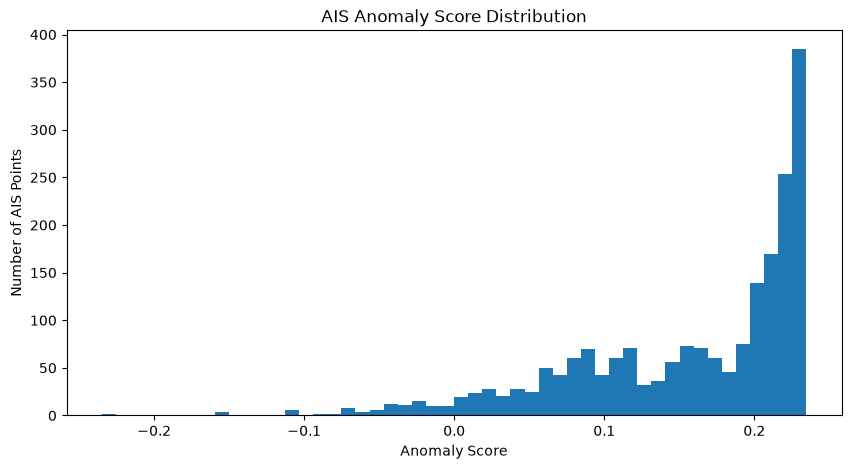

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    results["anomaly_score"],
    bins=50
)

plt.xlabel("Anomaly Score")
plt.ylabel("Number of AIS Points")
plt.title("AIS Anomaly Score Distribution")

plt.show()

In [19]:
anomaly_report = anomalies[
    [
        "MMSI",
        "TIMESTAMP",
        "LAT",
        "LON",
        "SOG",
        "COG",
        "anomaly_score"
    ]
].copy()

anomaly_report["risk_level"] = pd.cut(
    anomaly_report["anomaly_score"],
    bins=[-float("inf"), -0.15, -0.05, float("inf")],
    labels=["High", "Medium", "Low"]
)

display(anomaly_report.head(20))

,MMSI,TIMESTAMP,LAT,LON,SOG,COG,anomaly_score,risk_level
35761,616620391,1719824218,37.087103,25.147033,8.6,69.0,-0.234801,High
37181,616620391,1719825082,37.086550,25.128835,25.2,301.1,-0.225773,High
37413,616620391,1719825220,37.104810,25.126970,32.4,21.2,-0.217113,High
43267,616620391,1719828093,37.463177,25.323898,1.6,0.0,-0.200067,High
33133,616620391,1719822734,36.972515,24.973027,31.9,23.3,-0.194039,High
44061,616620391,1719828632,37.461987,25.322853,11.2,227.9,-0.181544,High
37065,616620391,1719824999,37.084838,25.137083,10.8,254.0,-0.168548,High
35835,616620391,1719824261,37.087518,25.147922,2.1,55.3,-0.155344,High
36753,616620391,1719824819,37.087095,25.147065,4.7,276.1,-0.154714,High
44015,616620391,1719828592,37.463237,25.324312,3.0,211.8,-0.154014,High


In [20]:
def clean_ais_data(df):
    df = df.copy()

    # Remove duplicate AIS records 1
    df = df.drop_duplicates()

    # Remove invalid coordinates2
    df = df[
        df["LAT"].between(-90, 90) &
        df["LON"].between(-180, 180)
    ]

    # Remove invalid speed values3
    df = df[
        df["SOG"].between(0, 60)
    ]

    # Sort by vessel and time4
    df = df.sort_values(
        ["MMSI", "TIMESTAMP"]
    )

    return df


clean_df = clean_ais_data(df)

print("Original rows:", len(df))
print("Clean rows:", len(clean_df))
print("Removed rows:", len(df) - len(clean_df))

Original rows: 50000
Clean rows: 49943
Removed rows: 57


In [21]:
pip install pandera

     ---------------------------------------- 0.0/110.2 kB ? eta -:--:--
     ---------------------------------------- 0.0/110.2 kB ? eta -:--:--
     --- ------------------------------------ 10.2/110.2 kB ? eta -:--:--
     ---------- -------------------------- 30.7/110.2 kB 435.7 kB/s eta 0:00:01
     ---------- -------------------------- 30.7/110.2 kB 435.7 kB/s eta 0:00:01
     ------------- ----------------------- 41.0/110.2 kB 245.8 kB/s eta 0:00:01
     ------------- ----------------------- 41.0/110.2 kB 245.8 kB/s eta 0:00:01
     ------------- ----------------------- 41.0/110.2 kB 245.8 kB/s eta 0:00:01
     -------------------- ---------------- 61.4/110.2 kB 204.8 kB/s eta 0:00:01
     --------------------------- --------- 81.9/110.2 kB 229.7 kB/s eta 0:00:01
     ------------------------------ ------ 92.2/110.2 kB 228.2 kB/s eta 0:00:01
     ------------------------------ ------ 92.2/110.2 kB 228.2 kB/s eta 0:00:01
     ------------------------------ ------ 92.2/110.2 kB 228


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import pandera.pandas as pa

schema = pa.DataFrameSchema({
    "MMSI": pa.Column(int, nullable=False),
    "LAT": pa.Column(float, checks=pa.Check.in_range(-90, 90)),
    "LON": pa.Column(float, checks=pa.Check.in_range(-180, 180)),
    "SOG": pa.Column(float, checks=pa.Check.in_range(0, 60)),
    "COG": pa.Column(float, checks=pa.Check.in_range(0, 360))
})

validated_df = schema.validate(clean_df)

print("✅ Data validation passed!")
print("Validated rows:", len(validated_df))

✅ Data validation passed!
Validated rows: 49943


In [5]:
# Predict anomalies
predictions = model.predict(X)

# Add predictions
X["anomaly"] = predictions

# Calculate percentages
total = len(X)
anomaly_count = (X["anomaly"] == -1).sum()
normal_count = (X["anomaly"] == 1).sum()

print("Total ML records:", total)
print("Normal records:", normal_count)
print("Potential anomalies:", anomaly_count)

print(f"Normal: {normal_count / total * 100:.2f}%")
print(f"Anomalies: {anomaly_count / total * 100:.2f}%")

NameError: name 'model' is not defined

In [6]:
from sklearn.ensemble import IsolationForest

feature_cols = [
    "SOG",
    "COG",
    "time_gap",
    "distance_km",
    "speed_change",
    "course_change"
]

X = features[feature_cols].copy()

model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

model.fit(X)

print("Training data:", X.shape)
print("✅ Model trained")

NameError: name 'features' is not defined

In [7]:
import numpy as np
from sklearn.ensemble import IsolationForest

# Create features
features = vessel[
    ["SOG", "COG", "time_gap", "distance_km", "ais_gap_anomaly"]
].copy()

features["speed_change"] = vessel["SOG"].diff().abs()

features["course_change"] = (
    vessel["COG"].diff().abs().clip(upper=180)
)

# Clean
features = features.replace(
    [np.inf, -np.inf], np.nan
).dropna()

# ML features
feature_cols = [
    "SOG",
    "COG",
    "time_gap",
    "distance_km",
    "speed_change",
    "course_change"
]

X = features[feature_cols].copy()

# Train Isolation Forest
model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

model.fit(X)

print("Feature dataset:", features.shape)
print("ML dataset:", X.shape)
print("✅ Isolation Forest trained")

NameError: name 'vessel' is not defined

In [8]:
import pandas as pd
import numpy as np
from haversine import haversine
from sklearn.ensemble import IsolationForest

# 1. Load data
file_path = "../data/final_syros/final_syros/all_filtered_ais.csv"
df = pd.read_csv(file_path, nrows=50000)

# 2. Find best moving vessel
vessel_stats = (
    df.groupby("MMSI")
    .agg(
        ais_points=("MMSI", "size"),
        moving_points=("SOG", lambda x: (x > 0).sum()),
        avg_speed=("SOG", "mean"),
        max_speed=("SOG", "max")
    )
    .sort_values("moving_points", ascending=False)
)

best_vessel_id = vessel_stats.index[0]

# 3. Create vessel dataframe
vessel = df[df["MMSI"] == best_vessel_id].copy()

# 4. Feature engineering
vessel["time_gap"] = vessel["TIMESTAMP"].diff()
vessel["speed_change"] = vessel["SOG"].diff().abs()

delta_cog = vessel["COG"].diff().abs()
vessel["course_change"] = np.minimum(delta_cog, 360 - delta_cog)

vessel["ais_gap_anomaly"] = vessel["time_gap"] > 600

# 5. Distance calculation
vessel["prev_lat"] = vessel["LAT"].shift(1)
vessel["prev_lon"] = vessel["LON"].shift(1)

vessel["distance_km"] = vessel.apply(
    lambda row: haversine(
        (row["prev_lat"], row["prev_lon"]),
        (row["LAT"], row["LON"])
    ) if pd.notna(row["prev_lat"]) else 0,
    axis=1
)

# 6. Build ML features
features = vessel[
    [
        "SOG",
        "COG",
        "time_gap",
        "distance_km",
        "ais_gap_anomaly",
        "speed_change",
        "course_change"
    ]
].copy()

features = features.replace([np.inf, -np.inf], np.nan).dropna()

feature_cols = [
    "SOG",
    "COG",
    "time_gap",
    "distance_km",
    "speed_change",
    "course_change"
]

X = features[feature_cols].copy()

# 7. Train model
model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

model.fit(X)

# 8. Predict
X["anomaly"] = model.predict(X)

print("Selected vessel:", best_vessel_id)
print("Vessel rows:", len(vessel))
print("ML rows:", len(X))
print("✅ Model trained successfully")
print(X["anomaly"].value_counts())

Selected vessel: 616620391
Vessel rows: 2039
ML rows: 2038
✅ Model trained successfully
anomaly
 1    1936
-1     102
Name: count, dtype: int64


In [9]:
X["anomaly_score"] = model.decision_function(
    X[feature_cols]
)

anomalies = X[
    X["anomaly"] == -1
].sort_values("anomaly_score")

print("Potential anomalies:", len(anomalies))

display(anomalies.head(20))

Potential anomalies: 102


,SOG,COG,time_gap,distance_km,speed_change,course_change,anomaly,anomaly_score
35761,8.6,69.0,1462.0,19.664373,23.7,30.1,-1,-0.240002
37181,25.2,301.1,83.0,0.756012,14.4,47.1,-1,-0.228754
37413,32.4,21.2,138.0,2.037149,7.2,80.1,-1,-0.220083
43267,1.6,0.0,81.0,0.198521,8.1,64.9,-1,-0.200571
33133,31.9,23.3,88.0,1.461333,2.0,50.6,-1,-0.191756
44061,11.2,227.9,40.0,0.189438,8.2,16.1,-1,-0.186088
37065,10.8,254.0,120.0,0.656417,1.1,1.4,-1,-0.163539
35835,2.1,55.3,43.0,0.091315,6.5,13.7,-1,-0.161855
44015,3.0,211.8,60.0,0.030777,3.0,91.1,-1,-0.153042
36753,4.7,276.1,51.0,0.074790,4.0,26.1,-1,-0.151292


In [10]:
cog_diff = vessel["COG"].diff().abs()

vessel["course_change_circular"] = np.minimum(
    cog_diff,
    360 - cog_diff
)

print(
    vessel["course_change_circular"].describe()
)

count    2038.000000
mean       14.711580
std        32.477428
min         0.000000
25%         0.100000
50%         0.200000
75%         2.800000
max       179.800000
Name: course_change_circular, dtype: float64


In [11]:
feature_cols = [
    "SOG",
    "COG",
    "time_gap",
    "distance_km",
    "speed_change",
    "course_change_circular"
]

X = vessel[feature_cols].copy()

X = X.replace(
    [np.inf, -np.inf], np.nan
).dropna()

model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

model.fit(X)

X["anomaly"] = model.predict(X)
X["anomaly_score"] = model.decision_function(
    X[feature_cols]
)

print("ML dataset:", X.shape)
print(X["anomaly"].value_counts())
print("✅ Improved model trained")

ML dataset: (2038, 8)
anomaly
 1    1936
-1     102
Name: count, dtype: int64
✅ Improved model trained


In [12]:
# Anomaly scores
normal_scores = X.loc[
    X["anomaly"] == 1,
    "anomaly_score"
]

anomaly_scores = X.loc[
    X["anomaly"] == -1,
    "anomaly_score"
]

print("Normal score mean:", normal_scores.mean())
print("Anomaly score mean:", anomaly_scores.mean())

print("Normal score range:",
      normal_scores.min(), "to", normal_scores.max())

print("Anomaly score range:",
      anomaly_scores.min(), "to", anomaly_scores.max())

Normal score mean: 0.16729816927960878
Anomaly score mean: -0.06068048500727861
Normal score range: 0.00020077644120586324 to 0.23065483938932235
Anomaly score range: -0.24000176179375043 to -0.00113773316683341


In [13]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

model_path = "../models/isolation_forest_v1.joblib"

joblib.dump(model, model_path)

print("✅ Model saved!")
print("Path:", model_path)

✅ Model saved!
Path: ../models/isolation_forest_v1.joblib


In [15]:
import json

feature_config = {
    "features": feature_cols,
    "model": "IsolationForest",
    "version": "v1"
}

config_path = "../models/feature_config.json"

with open(config_path, "w") as f:
    json.dump(feature_config, f, indent=4)

print("✅ Feature configuration saved!")
print("Path:", config_path)

✅ Feature configuration saved!
Path: ../models/feature_config.json


In [16]:
pip install mlflow

     ---------------------------------------- 0.0/50.0 kB ? eta -:--:--
     -------- ------------------------------- 10.2/50.0 kB ? eta -:--:--
     --------------- ---------------------- 20.5/50.0 kB 217.9 kB/s eta 0:00:01
     ------------------------------- ------ 41.0/50.0 kB 281.8 kB/s eta 0:00:01
     -------------------------------------- 50.0/50.0 kB 282.1 kB/s eta 0:00:00
     ---------------------------------------- 0.0/50.9 kB ? eta -:--:--
     ------------------------ --------------- 30.7/50.9 kB 1.3 MB/s eta 0:00:01
     ---------------------------------------- 50.9/50.9 kB 1.3 MB/s eta 0:00:00
  Using cached sqlalchemy-2.0.52-cp311-cp311-win_amd64.whl.metadata (9.9 kB)
     ---------------------------------------- 0.0/44.2 kB ? eta -:--:--
     --------------------------- ------------ 30.7/44.2 kB 1.4 MB/s eta 0:00:01
     --------------------------- ------------ 30.7/44.2 kB 1.4 MB/s eta 0:00:01
     --------------------------- ------------ 30.7/44.2 kB 1.4 MB/s eta 0:


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
mlflow --version

NameError: name 'mlflow' is not defined

In [18]:
import mlflow

print(mlflow.__version__)

3.16.0


In [19]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("AIS_Maritime_Anomaly_Detection")

with mlflow.start_run():

    # Log model parameters
    mlflow.log_param("model", "IsolationForest")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("contamination", 0.05)

    # Log metrics
    anomaly_count = (X["anomaly"] == -1).sum()
    total_count = len(X)
    anomaly_rate = anomaly_count / total_count

    mlflow.log_metric("total_records", total_count)
    mlflow.log_metric("anomaly_count", anomaly_count)
    mlflow.log_metric("anomaly_rate", anomaly_rate)

    # Log trained model
    mlflow.sklearn.log_model(
        model,
        "isolation_forest"
    )

print("✅ Experiment logged to MLflow")

2026/09/04 19:49:28 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/04 19:49:28 INFO mlflow.store.db.utils: Updating database tables
2026/09/04 19:49:29 INFO mlflow.tracking.fluent: Experiment with name 'AIS_Maritime_Anomaly_Detection' does not exist. Creating a new experiment.
2026/09/04 19:49:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Experiment logged to MLflow


In [20]:
experiment = mlflow.get_experiment_by_name(
    "AIS_Maritime_Anomaly_Detection"
)

print("Experiment ID:", experiment.experiment_id)
print("Experiment name:", experiment.name)

Experiment ID: 1
Experiment name: AIS_Maritime_Anomaly_Detection


In [21]:
runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

display(
    runs[
        [
            "run_id",
            "params.model",
            "params.n_estimators",
            "params.contamination",
            "metrics.anomaly_count",
            "metrics.anomaly_rate"
        ]
    ]
)

,run_id,params.model,params.n_estimators,params.contamination,metrics.anomaly_count,metrics.anomaly_rate
0,4dc4e2e931ba4cbe9d78b17414decc2f,IsolationForest,200,0.05,102.0,0.050049


In [22]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")

mlflow.set_experiment("AIS_Maritime_Anomaly_Detection")

with mlflow.start_run():

    mlflow.log_param("model", "IsolationForest")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("contamination", 0.05)

    anomaly_count = int((X["anomaly"] == -1).sum())
    total_count = len(X)
    anomaly_rate = anomaly_count / total_count

    mlflow.log_metric("total_records", total_count)
    mlflow.log_metric("anomaly_count", anomaly_count)
    mlflow.log_metric("anomaly_rate", anomaly_rate)

    mlflow.sklearn.log_model(
        model,
        "isolation_forest"
    )

print("✅ MLflow run logged successfully!")

2026/09/04 19:53:26 INFO mlflow.tracking.fluent: Experiment with name 'AIS_Maritime_Anomaly_Detection' does not exist. Creating a new experiment.
2026/09/04 19:53:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run nimble-skink-277 at: http://127.0.0.1:5000/#/experiments/1/runs/ae0cfba07d3f4d08bba8f36fc90886c2
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
✅ MLflow run logged successfully!


In [23]:
from mlflow import MlflowClient

client = MlflowClient()

experiment = mlflow.get_experiment_by_name(
    "AIS_Maritime_Anomaly_Detection"
)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["start_time DESC"],
    max_results=1
)

run_id = runs.iloc[0]["run_id"]

model_uri = f"runs:/{run_id}/isolation_forest"

registered_model = mlflow.register_model(
    model_uri=model_uri,
    name="AIS_IsolationForest"
)

print("✅ Model registered!")
print("Model:", registered_model.name)
print("Version:", registered_model.version)

Successfully registered model 'AIS_IsolationForest'.
2026/09/04 19:54:13 WARNING mlflow.tracking._model_registry.fluent: Run with id ae0cfba07d3f4d08bba8f36fc90886c2 has no artifacts at artifact path 'isolation_forest', registering model based on models:/m-8faf49be051849be8669032a84c7e83c instead
2026/09/04 19:54:13 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: AIS_IsolationForest, version 1


✅ Model registered!
Model: AIS_IsolationForest
Version: 1


Created version '1' of model 'AIS_IsolationForest'.


In [24]:
import os

os.makedirs("../data/processed", exist_ok=True)

results = vessel.loc[
    X.index,
    ["MMSI", "TIMESTAMP", "LAT", "LON", "SOG", "COG"]
].copy()

results["anomaly"] = X["anomaly"]
results["anomaly_score"] = X["anomaly_score"]

results.to_csv(
    "../data/processed/anomaly_results.csv",
    index=False
)

print("✅ Real AIS results exported!")
print("Records:", len(results))
print("Anomalies:", (results["anomaly"] == -1).sum())

✅ Real AIS results exported!
Records: 2038
Anomalies: 102
